# EE446 - TinyML - Assignment 2

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

2026-06-01 21:44:58.050760: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-01 21:44:58.177755: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-01 21:44:58.665337: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-01 21:44:58.665415: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-01 21:44:58.668235: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Reading Data

In [2]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
# Drop columns that are not useful for this model
cols_to_drop = ['land', 'urgent', 'numfailedlogins', 'numoutboundcmds']
data = data.drop(columns=cols_to_drop)

# Check that the columns were removed
print(data.shape)
data.head()

(125973, 39)


,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
# Convert all non-normal classes into one binary label: attack
# normal stays normal; everything else becomes attack
data['attack'] = data['attack'].apply(lambda label: 'normal' if label == 'normal' else 'attack')

# Check the new binary class distribution
print(data['attack'].value_counts())

attack
normal    67343
attack    58630
Name: count, dtype: int64


In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
# Encode categorical columns into numerical values
label_encoders = {}

for col in ['protocoltype', 'service', 'flag', 'attack']:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    label_encoders[col] = encoder
    print(f"{col}: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")


protocoltype: {'icmp': 0, 'tcp': 1, 'udp': 2}
service: {'IRC': 0, 'X11': 1, 'Z39_50': 2, 'aol': 3, 'auth': 4, 'bgp': 5, 'courier': 6, 'csnet_ns': 7, 'ctf': 8, 'daytime': 9, 'discard': 10, 'domain': 11, 'domain_u': 12, 'echo': 13, 'eco_i': 14, 'ecr_i': 15, 'efs': 16, 'exec': 17, 'finger': 18, 'ftp': 19, 'ftp_data': 20, 'gopher': 21, 'harvest': 22, 'hostnames': 23, 'http': 24, 'http_2784': 25, 'http_443': 26, 'http_8001': 27, 'imap4': 28, 'iso_tsap': 29, 'klogin': 30, 'kshell': 31, 'ldap': 32, 'link': 33, 'login': 34, 'mtp': 35, 'name': 36, 'netbios_dgm': 37, 'netbios_ns': 38, 'netbios_ssn': 39, 'netstat': 40, 'nnsp': 41, 'nntp': 42, 'ntp_u': 43, 'other': 44, 'pm_dump': 45, 'pop_2': 46, 'pop_3': 47, 'printer': 48, 'private': 49, 'red_i': 50, 'remote_job': 51, 'rje': 52, 'shell': 53, 'smtp': 54, 'sql_net': 55, 'ssh': 56, 'sunrpc': 57, 'supdup': 58, 'systat': 59, 'telnet': 60, 'tftp_u': 61, 'tim_i': 62, 'time': 63, 'urh_i': 64, 'urp_i': 65, 'uucp': 66, 'uucp_path': 67, 'vmnet': 68, 'whois'

In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

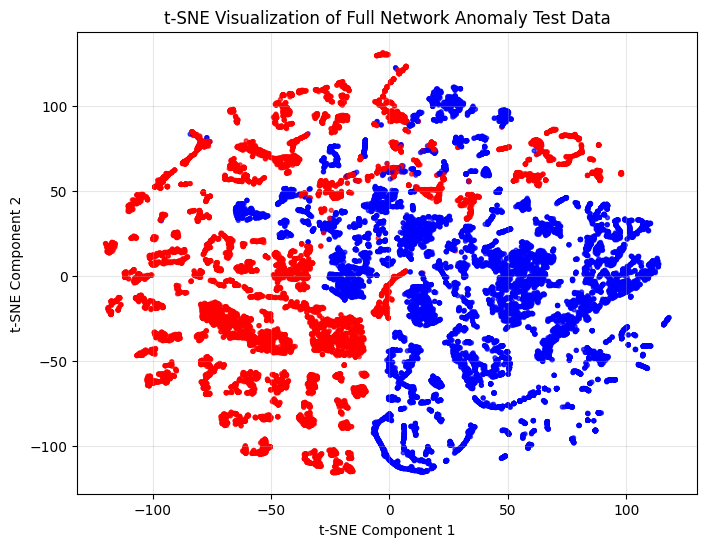

In [11]:
from sklearn.manifold import TSNE

X_vis = X_test
y_vis = y_test.ravel()

perplexity = min(30, X_vis.shape[0] - 1)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

X_tsne = tsne.fit_transform(X_vis)

colors = np.where(y_vis == 0, 'red', 'blue')  # 0 = attack, 1 = normal

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, s=8, alpha=0.7)
plt.title('t-SNE Visualization of Full Network Anomaly Test Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, alpha=0.3)
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

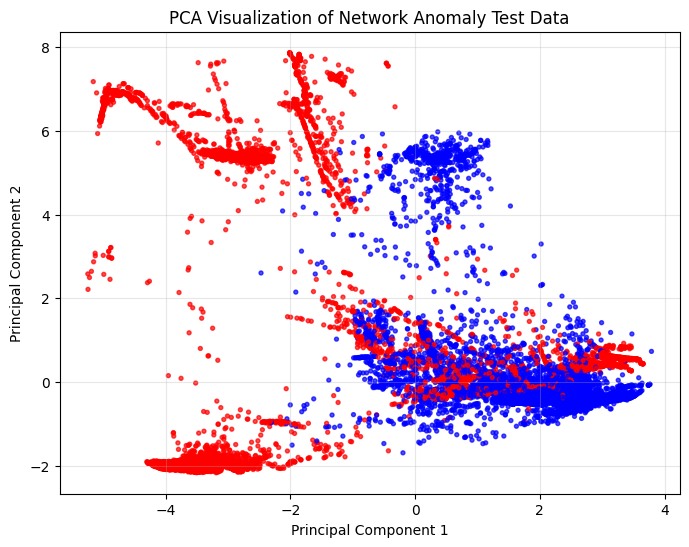

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test)

y_test_flat = y_test.ravel()
colors = np.where(y_test_flat == 0, 'red', 'blue')  # 0 = attack, 1 = normal

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=8, alpha=0.7)
plt.title('PCA Visualization of Network Anomaly Test Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

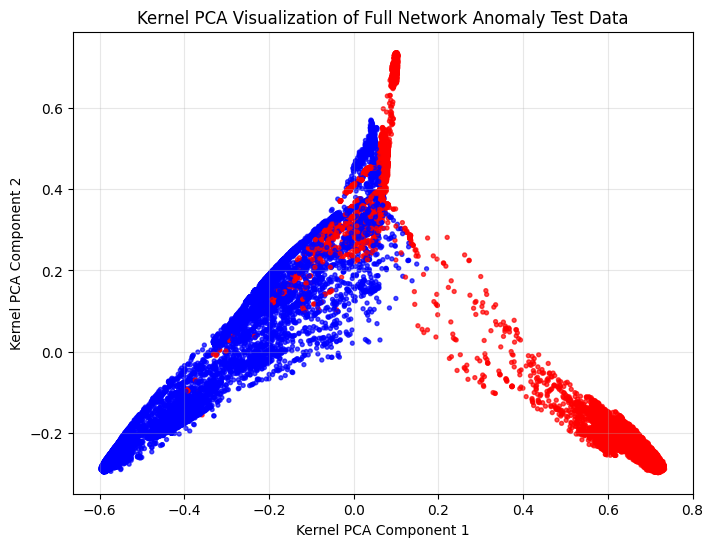

In [13]:
from sklearn.decomposition import KernelPCA

X_vis = X_test
y_vis = y_test.ravel()

kpca = KernelPCA(
    n_components=2,
    kernel='rbf',
    gamma=0.05
)

X_kpca = kpca.fit_transform(X_vis)

colors = np.where(y_vis == 0, 'red', 'blue')  # 0 = attack, 1 = normal

plt.figure(figsize=(8, 6))
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=colors, s=8, alpha=0.7)
plt.title('Kernel PCA Visualization of Full Network Anomaly Test Data')
plt.xlabel('Kernel PCA Component 1')
plt.ylabel('Kernel PCA Component 2')
plt.grid(True, alpha=0.3)
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [25]:
# Define the DNN model
base_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

base_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 32)                1248      
                                                                 
 dense_5 (Dense)             (None, 2)                 66        
                                                                 
Total params: 1314 (5.13 KB)
Trainable params: 1314 (5.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [26]:
#Compile model
base_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Train model
history = base_model.fit(
    X_train,
    y_train.ravel(),
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1260/1260 [==============================] - 4s 3ms/step - loss: 0.0650 - accuracy: 0.9794 - val_loss: 0.0226 - val_accuracy: 0.9946
Epoch 2/10
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0186 - accuracy: 0.9945 - val_loss: 0.0142 - val_accuracy: 0.9956
Epoch 3/10
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0130 - accuracy: 0.9956 - val_loss: 0.0105 - val_accuracy: 0.9966
Epoch 4/10
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0106 - accuracy: 0.9960 - val_loss: 0.0087 - val_accuracy: 0.9967
Epoch 5/10
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0090 - accuracy: 0.9967 - val_loss: 0.0095 - val_accuracy: 0.9965
Epoch 6/10
1260/1260 [==============================] - 6s 5ms/step - loss: 0.0080 - accuracy: 0.9968 - val_loss: 0.0064 - val_accuracy: 0.9978
Epoch 7/10
1260/1260 [==============================] - 4s 3ms/step - loss: 0.0070 - accuracy: 0.9970 - val_loss: 0.0065 - val_accuracy:

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

788/788 [==============================] - 2s 2ms/step
Classification Report for Base DNN Model
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11692
      normal       1.00      1.00      1.00     13503

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix for Base DNN Model
[[11661    31]
 [   35 13468]]


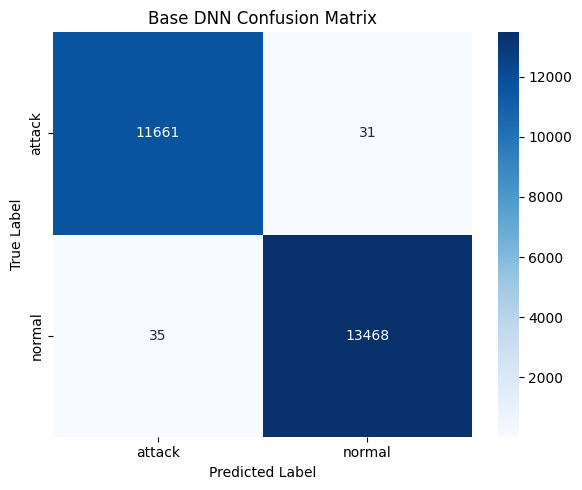

In [27]:
#Predict class probabilities, then convert to labels
base_probs = base_model.predict(X_test)
y_pred_base = np.argmax(base_probs, axis=1)
y_true = y_test.ravel()

#Classification report
print('Classification Report for Base DNN Model')
print(classification_report(y_true, y_pred_base, target_names=['attack', 'normal']))

#Confusion matrix
cm_base = confusion_matrix(y_true, y_pred_base, labels=[0, 1])
print('Confusion Matrix for Base DNN Model')
print(cm_base)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=['attack', 'normal'], yticklabels=['attack', 'normal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Base DNN Confusion Matrix')
plt.tight_layout()
plt.show()


In [28]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [29]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

# Convert the trained Keras model to a dynamically quantized TFLite model
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpeulz_yhs/assets


INFO:tensorflow:Assets written to: /tmp/tmpeulz_yhs/assets
2026-06-03 20:50:54.354124: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-03 20:50:54.354299: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-03 20:50:54.355700: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpeulz_yhs
2026-06-03 20:50:54.356752: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-03 20:50:54.356771: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpeulz_yhs
2026-06-03 20:50:54.360538: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-03 20:50:54.399177: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpeulz_yhs
2026-06-03 20:50:54.409192: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

In [19]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 100.84 KB
Quantized model size: 9.52 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Classification Report for Quantized TFLite Model
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11692
      normal       1.00      1.00      1.00     13503

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix for Quantized TFLite Model
[[11662    30]
 [   34 13469]]


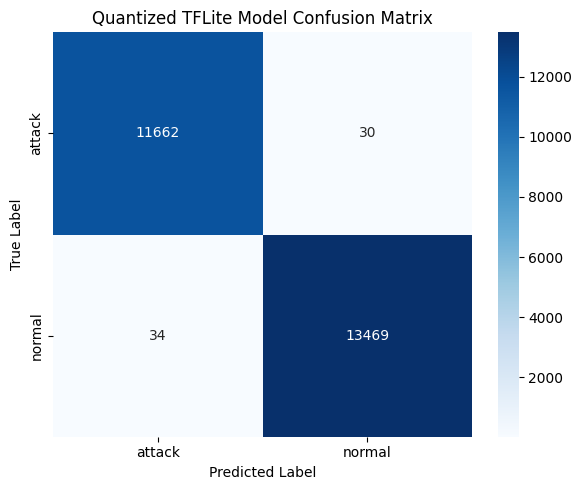

In [30]:
#Evaluate quantized TFLite model
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_index = input_details[0]['index']
output_index = output_details[0]['index']
input_dtype = input_details[0]['dtype']

#Resize the input tensor
interpreter.resize_tensor_input(input_index, [X_test.shape[0], X_test.shape[1]])
interpreter.allocate_tensors()

X_test_tflite = X_test.astype(input_dtype)
interpreter.set_tensor(input_index, X_test_tflite)
interpreter.invoke()

tflite_probs = interpreter.get_tensor(output_index)
y_pred_tflite = np.argmax(tflite_probs, axis=1)
y_true = y_test.ravel()

#Classification report
print('Classification Report for Quantized TFLite Model')
print(classification_report(y_true, y_pred_tflite, target_names=['attack', 'normal']))

#Confusion matrix
cm_tflite = confusion_matrix(y_true, y_pred_tflite, labels=[0, 1])
print('Confusion Matrix for Quantized TFLite Model')
print(cm_tflite)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tflite, annot=True, fmt='d', cmap='Blues',
            xticklabels=['attack', 'normal'], yticklabels=['attack', 'normal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Quantized TFLite Model Confusion Matrix')
plt.tight_layout()
plt.show()

## Converting tflite_model to C and create the header file

In [21]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [31]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [48]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare
Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.44208308523109213, 
    0.7511112872365361, -0.0077067070263992276, -0.004403133446771172, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.7257784945454897, -0.3681102129968653, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    0.7343425609306344, 1.2587542737799418, 1.0664013456654926, 
    -0.43907816809041417, -0.4801968475158174, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.110249223

In [49]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    1, 1, 0, 1, 0
};



In [46]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

# Converting 10 test samples excluding the first five samples
# These are samples 6 through 15 in human counting, or indices 5 through 14 in Python

Xtest = X_test[5:15, :]

print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    -0.09988256993763983, -0.12470615670462065, -0.747960738063091, 
    0.7511112872365361, -0.007501777400184666, -0.0038861304376410478, 
    -0.08948642202040107, 13.858672952656951, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, 10.253156170538698, 
    -0.7257784945454897, -0.3681102129968653, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    -0.5256641696702168, -0.809856740861921, -0.715543880134131, 
    -0.17441734820805624, -0.4478339589698615, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.21642633142264128, -0.1102492232

In [47]:
ytest=y_test[5:15]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 10;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[10][1] = {
    1, 0, 1, 0, 1, 1, 0, 0, 1, 0
};



## Creating INT8 quantized model

Model had to use INT8 quantization instead of dynamic range to work on Arduino

In [40]:
# Convert trained Keras model to TFLite float model first

input_shape = [1, X_train.shape[1]]

run_model = tf.function(lambda x: base_model(x))
concrete_func = run_model.get_concrete_function(
    tf.TensorSpec(input_shape, dtype=base_model.input.dtype)
)

converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func])
network_float_tflite = converter.convert()

# Save the float model to disk
open("network_float_model.tfl", "wb").write(network_float_tflite)

print("Float TFLite model saved as network_float_model.tfl")
print("Float model size:", len(network_float_tflite), "bytes")
print("Float model size:", len(network_float_tflite) / 1024, "KB")

Float TFLite model saved as network_float_model.tfl
Float model size: 6760 bytes
Float model size: 6.6015625 KB


2026-06-03 21:10:56.072914: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 21:10:56.073536: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-06-03 21:10:56.075390: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-06-03 21:10:56.077462: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 21:10:56.077748: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/

In [41]:
# INT8 quantization using representative dataset

def representative_dataset():
    for i in range(min(100, X_train.shape[0])):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]


converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func])
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

converter.representative_dataset = representative_dataset

network_quantized_tflite = converter.convert()

# Save the quantized model to disk
open("network_quantized_model.tfl", "wb").write(network_quantized_tflite)

print("INT8 quantized model saved as network_quantized_model.tfl")
print("INT8 model size:", len(network_quantized_tflite), "bytes")
print("INT8 model size:", len(network_quantized_tflite) / 1024, "KB")

INT8 quantized model saved as network_quantized_model.tfl
INT8 model size: 3208 bytes
INT8 model size: 3.1328125 KB


2026-06-03 21:11:20.082924: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 21:11:20.083083: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-06-03 21:11:20.084074: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-06-03 21:11:20.085887: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 21:11:20.085950: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/

In [42]:
# Generate C header file from INT8 quantized model

with open("network_quantized_model.tfl", "rb") as f:
    model_bytes = f.read()

model_array = np.frombuffer(model_bytes, dtype=np.uint8)

c_code = c_writer.create_array(model_array, "unsigned char", "network_model")
header = c_writer.create_header(c_code, "network_model")

with open("network_model.h", "w") as f:
    f.write(header)

print("network_model.h generated from INT8 quantized model.")

network_model.h generated from INT8 quantized model.


In [45]:
# Evaluate INT8 quantized TFLite model

interpreter = tf.lite.Interpreter(model_path="network_quantized_model.tfl")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

print("Input quantization:", input_scale, input_zero_point)
print("Output quantization:", output_scale, output_zero_point)

y_pred_quantized = []

for i in range(X_test.shape[0]):
    input_data = X_test[i:i+1].astype(np.float32)

    # Quantize float input to int8
    input_data = input_data / input_scale + input_zero_point
    input_data = np.round(input_data)
    input_data = np.clip(input_data, -128, 127).astype(np.int8)

    interpreter.set_tensor(input_details[0]["index"], input_data)
    interpreter.invoke()

    output_data = interpreter.get_tensor(output_details[0]["index"])

    # Dequantize int8 output back to float
    output_float = (output_data.astype(np.float32) - output_zero_point) * output_scale

    # Flipped class interpretation:
    # output >= 0.5 means class 0
    # output < 0.5 means class 1
    pred_class = 0 if output_float[0][0] >= 0.5 else 1

    y_pred_quantized.append(pred_class)

y_pred_quantized = np.array(y_pred_quantized)
y_true = y_test.ravel()

print("INT8 Quantized Model Accuracy:", accuracy_score(y_true, y_pred_quantized))
print(classification_report(y_true, y_pred_quantized))

Input quantization: 0.06475375592708588 -30
Output quantization: 0.00390625 -128
INT8 Quantized Model Accuracy: 0.9972613613812265
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11692
           1       1.00      1.00      1.00     13503

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

